# Model 2: Random Forest

This notebook builds and tunes random forest models.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    repo_root = Path("/Users/leshakamadara/bank-LM-prediction")
sys.path.insert(0, str(repo_root))

from src.data import get_split
from src.evaluate import cv_report, save_result
from src.pipeline import build

X_train, X_test, y_train, y_test = get_split()
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import json
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_params_path = repo_root / "reports" / "best_params.json"


## 3. Random forest

In [4]:
forest_estimator = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
forest_pipeline = build(forest_estimator)
forest_result = cv_report("Random forest", forest_pipeline, X_train, y_train)
report_path = repo_root / "reports" / "model_comparison.csv"
save_result(forest_result, report_path)
forest_pipeline.fit(X_train, y_train)

if report_path.exists() and report_path.stat().st_size > 0:
    all_results = pd.read_csv(report_path)
else:
    all_results = pd.DataFrame([forest_result])
display(all_results.sort_values("pr_auc_mean", ascending=False))

,name,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,train_pr_auc_mean,train_pr_auc_std,fit_time_mean
9,HistGradientBoosting-tuned,0.448903,0.011179,0.797768,0.000896,0.446291,0.007269,0.347402,0.010083,0.624439,0.007023,0.519569,0.006918,4.936136
4,HistGradientBoosting,0.440183,0.009540,0.795136,0.002760,0.445864,0.009918,0.350782,0.012016,0.612151,0.006734,0.522408,0.009359,2.392582
2,Random forest-tuned,0.437522,0.013917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.700831,0.003898,32.614016
10,Random forest,0.411338,0.015292,0.776984,0.004182,0.424500,0.020910,0.476966,0.016705,0.382652,0.024176,1.000000,0.000000,3.186421
1,Decision tree-tuned,0.402857,0.013289,0.756731,0.008299,0.360107,0.005740,0.246054,0.004716,0.671713,0.017116,0.490113,0.001235,0.371310
3,KNeighbors-tuned,0.388705,0.010675,0.754646,0.001279,0.237650,0.011928,0.671733,0.030047,0.144409,0.007865,1.000000,0.000000,0.048373
8,Decision tree depth 6 leaf 50,0.347166,0.007796,0.749013,0.002266,0.392258,0.008481,0.300969,0.015612,0.566303,0.025456,0.365758,0.002196,0.294874
0,KNeighbors,0.335516,0.011747,0.729144,0.005470,0.256434,0.011336,0.607519,0.029026,0.162609,0.007966,0.451202,0.002987,0.046876
6,Decision tree gini,0.176376,0.007513,0.608932,0.009150,0.308913,0.015589,0.307673,0.013535,0.310328,0.018693,1.000000,0.000000,0.642065
7,Decision tree entropy,0.175388,0.007725,0.609096,0.008593,0.308134,0.015314,0.301806,0.017359,0.314819,0.013549,1.000000,0.000000,0.708349


## Decision and reason

A forest averages many randomized trees. This reduces the variance of any one tree, so it usually generalizes better than a single unlimited-depth tree.

## 7. Random forest feature importances

,feature,importance
8,num__balance_log,0.112074
1,num__balance,0.111398
2,num__day,0.097122
0,num__age,0.095774
3,num__campaign,0.055942
51,cat__poutcome_success,0.032987
4,num__pdays,0.032466
36,cat__contact_unknown,0.024398
7,num__has_debt,0.018953
5,num__previous,0.018188


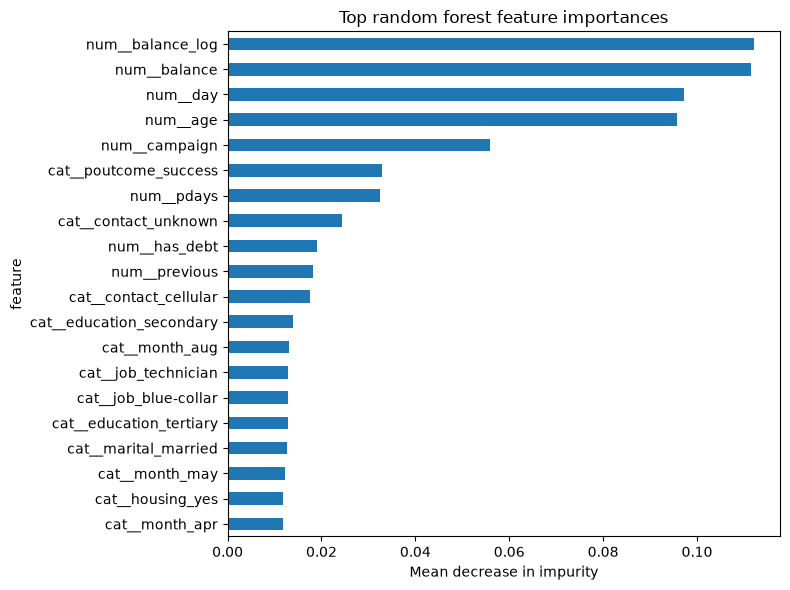

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src").exists():
    repo_root = Path("/Users/leshakamadara/bank-LM-prediction")
sys.path.insert(0, str(repo_root))

if "X_train" not in globals() or "y_train" not in globals():
    from src.data import get_split

    X_train, _, y_train, _ = get_split()
if "build" not in globals():
    from src.pipeline import build

if "forest_pipeline" not in globals() or not hasattr(
    forest_pipeline.named_steps["model"], "feature_importances_"
):
    forest_pipeline = build(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )
    )
    forest_pipeline.fit(X_train, y_train)

feature_names = forest_pipeline.named_steps["prep"].get_feature_names_out()
importances = forest_pipeline.named_steps["model"].feature_importances_
importance_table = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_table = importance_table.sort_values("importance", ascending=False)
display(importance_table.head(20))

importance_table.head(20).sort_values("importance").plot.barh(
    x="feature", y="importance", legend=False, figsize=(8, 6)
)
plt.title("Top random forest feature importances")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Decision and reason

The importance names come from the fitted `prep` step, so one-hot category names remain connected to their original variables. These values describe how much the forest used each feature to reduce impurity; they are useful for interpretation but are not causal effects.

## 2. Random-forest randomized search

In [ ]:
forest_pipeline = build(
    RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )
)
forest_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 6, 10, 15, 20],
    "model__min_samples_leaf": [1, 5, 10, 25, 50],
    "model__max_features": ["sqrt", "log2", None, 0.5],
}

forest_search = RandomizedSearchCV(
    forest_pipeline,
    param_distributions=forest_distributions,
    n_iter=25,
    scoring="average_precision",
    cv=folds,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
)
forest_search.fit(X_train, y_train)
print("Best random-forest parameters:", forest_search.best_params_)
print(f"Best CV PR-AUC: {forest_search.best_score_:.4f}")

Best random-forest parameters: {'model__n_estimators': 500, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV PR-AUC: 0.4375


In [ ]:
forest_cv_results = pd.DataFrame(forest_search.cv_results_)
forest_best_row = forest_cv_results.loc[forest_search.best_index_]
forest_best_result = {
    "name": "Random forest-tuned",
    "pr_auc_mean": forest_best_row["mean_test_score"],
    "pr_auc_std": forest_best_row["std_test_score"],
    "train_pr_auc_mean": forest_best_row["mean_train_score"],
    "train_pr_auc_std": forest_best_row["std_train_score"],
    "roc_auc_mean": float("nan"),
    "roc_auc_std": float("nan"),
    "f1_mean": float("nan"),
    "f1_std": float("nan"),
    "precision_mean": float("nan"),
    "precision_std": float("nan"),
    "recall_mean": float("nan"),
    "recall_std": float("nan"),
    "fit_time_mean": forest_best_row["mean_fit_time"],
}
save_result(forest_best_result, report_path)

forest_top10 = forest_cv_results.sort_values("rank_test_score").head(10)
forest_top10[["rank_test_score", "mean_test_score", "std_test_score", "param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_leaf", "param_model__max_features"]]

,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
22,1,0.437522,0.013917,500,20,10,0.5
19,2,0.435176,0.016163,200,20,5,0.5
13,3,0.433585,0.009700,100,None,25,0.5
10,4,0.433452,0.011913,200,None,10,sqrt
3,5,0.433341,0.010878,300,10,10,None
0,6,0.433338,0.010353,200,10,10,None
6,7,0.433116,0.011834,200,20,10,sqrt
18,8,0.432967,0.010673,500,10,10,0.5
8,9,0.429473,0.012391,300,15,5,log2
17,10,0.427198,0.009727,100,20,50,None


## Decision and reason

The randomized search already measured the selected forest with five-fold average precision, so the result row reuses that recorded CV score instead of fitting another five expensive forests. The top rows show whether deeper trees, larger leaves, more estimators, or the feature-sampling choice matters most for average precision.

## Preserve best parameters

In [ ]:

if best_params_path.exists() and best_params_path.stat().st_size > 0:
    best_params = json.loads(best_params_path.read_text())
else:
    best_params = {}
best_params["RandomForest-tuned"] = forest_search.best_params_
best_params_path.parent.mkdir(parents=True, exist_ok=True)
best_params_path.write_text(json.dumps(best_params, indent=2) + "\n")
display(pd.DataFrame(best_params).T)


## Model Comparison

In [ ]:

report_path = repo_root / "reports" / "model_comparison.csv"
if report_path.exists() and report_path.stat().st_size > 0:
    all_results = pd.read_csv(report_path)
    rf_results = all_results[all_results["name"].str.contains("Random forest", case=False)]
    display(rf_results.sort_values("pr_auc_mean", ascending=False))
